### Part A – Theoretical Foundation

#### Q1. What is Inferential Statistics?

Inferential statistics is the process of using sample data to draw conclusions or make predictions about a larger population.
 It includes methods such as hypothesis testing, confidence intervals, and statistical tests.


#### Q2. What is Hypothesis Testing and its Components?

 Hypothesis testing is a statistical method used to determine whether there is enough evidence to support a claim about a population. 
 Its main components are the null hypothesis (H₀), alternative hypothesis (H₁), significance level (α), test statistic, p-value, and decision.

#### Q3. Explain Confidence Interval and Critical Value.

A confidence interval provides a range of values within which a population parameter is expected to lie with a specified level of confidence, such as 95%. A critical value is a cutoff point used to determine whether a test statistic falls in the rejection region.


#### Q4. Define p-value.

A p-value is the probability of obtaining a result as extreme as, or more extreme than, the observed result when the null hypothesis is true. If the p-value is less than the significance level, usually 0.05, we reject H₀.


#### Q5. Differentiate Type I and Type II Errors.

A Type I error occurs when a true null hypothesis is incorrectly rejected, known as a false positive. A Type II error occurs when a false null hypothesis is not rejected, known as a false negative.

#### Q6. Give brief descriptions of z-test, t-test, chi-square test, and ANOVA test.

- **z-test:** Used to test means or proportions under appropriate normality/large-sample conditions, especially when population variance is known.
- **t-test:** Used to compare the means of two groups when the population standard deviation is unknown.
- **Chi-square test:** Used to determine whether two categorical variables are significantly associated.
- **ANOVA test:** Used to determine whether the means of three or more groups are significantly different.

#### Q7. What is Covariance?

Covariance measures how two numerical variables change together. Positive covariance indicates that the variables tend to increase together, while negative covariance indicates that one variable tends to increase when the other decreases.

#### Q8. What is Correlation?

Correlation measures the strength and direction of the linear relationship between two numerical variables. Its value ranges from -1 to +1, where values close to +1 indicate a strong positive relationship and values close to -1 indicate a strong negative relationship.

### Part B - Data Analysis & Testing

##### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("All required libraries imported successfully.")


All required libraries imported successfully.


#### Loading the Dataset

In [3]:
df = pd.read_csv("../Dataset/health_records.csv")
print("Dataset Loaded successfully")

Dataset Loaded successfully


In [4]:
print(f"Number of records: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of records: 1000
Number of variables: 15


In [5]:
#display the first 5 records
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,8938f04f-551e-4542-a637-66c17685e546,26-35,35,61,Male,South,Non-Smoker,Weekly,27.28,134.20,False,False,180.10,101.50,2026-07-16
1,7669cb30-42c0-4953-be69-9697421b9ad2,46-60,57,59,Male,East,Former Smoker,Weekly,20.61,144.70,False,True,205.20,91.60,2026-07-29
2,f41c6f7b-833a-4d39-a0e0-d50996ad4fcf,60+,73,62,Female,East,Former Smoker,Weekly,27.15,148.90,False,False,217.30,104.00,2026-07-08
3,157d435c-f498-4be1-99ed-6559fd86f91d,46-60,52,54,Female,East,Former Smoker,Weekly,21.46,141.10,True,False,194.20,97.80,2025-10-24
4,677df98b-6bd6-4540-ba76-b3d404c7539b,36-45,38,75,Male,South,Former Smoker,Weekly,24.25,125.40,False,False,148.20,85.70,2026-01-23


#### Dataset Information and Data Types

Before performing statistical analysis, we examine the structure of the dataset,
including the number of records, variables, data types, and non-null values.
This helps us understand whether the dataset is ready for further analysis.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           1000 non-null   str    
 1   age_group           1000 non-null   str    
 2   age                 1000 non-null   int64  
 3   weight              1000 non-null   int64  
 4   gender              1000 non-null   str    
 5   region              1000 non-null   str    
 6   smoking_status      1000 non-null   str    
 7   exercise_frequency  1000 non-null   str    
 8   bmi                 1000 non-null   float64
 9   blood_pressure      1000 non-null   float64
 10  diabetes            1000 non-null   bool   
 11  hypertension        1000 non-null   bool   
 12  cholesterol_level   1000 non-null   float64
 13  glucose_level       1000 non-null   float64
 14  visit_date          1000 non-null   str    
dtypes: bool(2), float64(4), int64(2), str(7)
memory usage: 177.2 KB


In [7]:
# Check the number of rows and columns

rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 1000
Number of Columns: 15


In [8]:
# Display all column names

print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- record_id
- age_group
- age
- weight
- gender
- region
- smoking_status
- exercise_frequency
- bmi
- blood_pressure
- diabetes
- hypertension
- cholesterol_level
- glucose_level
- visit_date


In [9]:
# Check for missing values in each column

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
record_id             0
age_group             0
age                   0
weight                0
gender                0
region                0
smoking_status        0
exercise_frequency    0
bmi                   0
blood_pressure        0
diabetes              0
hypertension          0
cholesterol_level     0
glucose_level         0
visit_date            0
dtype: int64


In [10]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


#### Data Cleaning and Validation

Before performing statistical tests, the dataset is checked for missing values,
duplicate records, incorrect data types, invalid categorical values, and
unrealistic numerical values.

This step ensures that the dataset is suitable for reliable statistical analysis.

In [11]:
# Check missing values in every column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\nMissing values are present and require treatment.")

Missing values in each column:
record_id             0
age_group             0
age                   0
weight                0
gender                0
region                0
smoking_status        0
exercise_frequency    0
bmi                   0
blood_pressure        0
diabetes              0
hypertension          0
cholesterol_level     0
glucose_level         0
visit_date            0
dtype: int64

No missing values found in the dataset.


In [12]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

if duplicates == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records found.")

Number of duplicate records: 0
No duplicate records found.


In [13]:
# Check unique values of categorical variables

categorical_columns = [
    "age_group",
    "gender",
    "region",
    "smoking_status",
    "exercise_frequency"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


age_group:
<ArrowStringArray>
['26-35', '46-60', '60+', '36-45', '18-25']
Length: 5, dtype: str

gender:
<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

region:
<ArrowStringArray>
['South', 'East', 'North', 'West']
Length: 4, dtype: str

smoking_status:
<ArrowStringArray>
['Non-Smoker', 'Former Smoker', 'Smoker']
Length: 3, dtype: str

exercise_frequency:
<ArrowStringArray>
['Weekly', 'Rarely', 'Daily', 'Never']
Length: 4, dtype: str


#### Generate descriptive statistics for numerical variables

In [14]:
df.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,47.92,67.80,24.30,136.50,189.89,104.57
std,18.65,12.47,3.62,16.72,27.56,16.49
min,18.00,40.00,16.00,90.00,120.00,65.00
25%,31.00,60.00,21.89,125.20,170.90,92.67
50%,47.00,67.00,24.33,136.30,189.95,103.60
75%,64.00,76.00,26.62,147.72,208.70,115.30
max,80.00,114.00,37.47,190.00,263.30,161.60


#### Categorical Variables

In [15]:
print("Gender:")
print(df["gender"].value_counts())

print("\nSmoking Status:")
print(df["smoking_status"].value_counts())

print("\nExercise Frequency:")
print(df["exercise_frequency"].value_counts())

print("\nAge Group:")
print(df["age_group"].value_counts())

Gender:
gender
Male      489
Female    488
Other      23
Name: count, dtype: int64

Smoking Status:
smoking_status
Non-Smoker       560
Former Smoker    222
Smoker           218
Name: count, dtype: int64

Exercise Frequency:
exercise_frequency
Weekly    362
Rarely    271
Daily     242
Never     125
Name: count, dtype: int64

Age Group:
age_group
60+      305
46-60    216
26-35    189
36-45    148
18-25    142
Name: count, dtype: int64


#### Diabetes Distribution

In [16]:
df["diabetes"].value_counts()

diabetes
False    990
True      10
Name: count, dtype: int64

In [17]:
df["diabetes"].value_counts(normalize=True) * 100

diabetes
False   99.00
True     1.00
Name: proportion, dtype: float64

#### Data Preparation

In [18]:
df["diabetes_numeric"] = df["diabetes"].astype(int)

In [19]:
df[["diabetes", "diabetes_numeric"]].head()

,diabetes,diabetes_numeric
0,False,0
1,False,0
2,False,0
3,True,1
4,False,0


## Hypothesis Formulation

### Hypothesis 1: Smoking Status and Diabetes

**H₀:** Smoking status has no association with diabetes prevalence.

**H₁:** Smoking status is associated with diabetes prevalence.

**Statistical Test:** Chi-square test of independence.

### Hypothesis 2: Smoking Status and BMI

**H₀:** There is no significant difference in mean BMI between smokers and non-smokers.

**H₁:** There is a significant difference in mean BMI between smokers and non-smokers.

**Statistical Test:** Independent samples t-test.

### Hypothesis 3: Age Group and Diabetes

**H₀:** Diabetes prevalence is the same across all age groups.

**H₁:** Diabetes prevalence differs across at least one age group.

**Statistical Test:** One-way ANOVA.

## Confidence Interval Analysis

A 95% confidence interval provides a range of plausible values for the population mean based on the sample.

The confidence interval is calculated using:

**CI = Mean ± Critical Value × Standard Error**

In [20]:
age = df["age"]

n = len(age)
mean = age.mean()
std = age.std()

confidence_level = 0.95
alpha = 1 - confidence_level

standard_error = std / np.sqrt(n)

t_critical = stats.t.ppf(
    1 - alpha / 2,
    df=n-1
)



In [21]:

margin_error = t_critical * standard_error

lower = mean - margin_error
upper = mean + margin_error

In [22]:
print("Mean Age:", mean)
print("Standard Error:", standard_error)
print("Critical Value:", t_critical)
print("Margin of Error:", margin_error)
print("95% Confidence Interval:", lower, "to", upper)

Mean Age: 47.917
Standard Error: 0.589830493456392
Critical Value: 1.9623414611334495
Margin of Error: 1.1574488323502798
95% Confidence Interval: 46.75955116764972 to 49.074448832350285


#### Confidence Intervals for All Important Numerical Variables

In [23]:
variables = [
    "age",
    "weight",
    "bmi",
    "blood_pressure",
    "cholesterol_level",
    "glucose_level"
]

In [24]:
ci_results=[]

In [25]:
for column in variables:
    
    data = df[column].dropna()
    
    n = len(data)
    mean = data.mean()
    std = data.std()
    
    standard_error = std / np.sqrt(n)
    
    t_critical = stats.t.ppf(
        0.975,
        df=n-1
    )
    

In [26]:
    margin_error = t_critical * standard_error
    
    lower = mean - margin_error
    upper = mean + margin_error
    

In [27]:
ci_results.append([column,n,mean,lower,upper])

In [28]:
    print(f"\n{column}")
    print(f"Mean = {mean:.2f}")
    print(f"95% CI = ({lower:.2f}, {upper:.2f})")


glucose_level
Mean = 104.57
95% CI = (103.54, 105.59)


In [29]:
ci_table = pd.DataFrame(

    ci_results,

    columns=[
        "Variable",
        "Sample Size",
        "Mean",
        "CI Lower",
        "CI Upper"
    ])

ci_table.round(3)

,Variable,Sample Size,Mean,CI Lower,CI Upper
0,glucose_level,1000,104.57,103.55,105.59


#### Interpretation

The calculated 95% confidence intervals provide plausible ranges for the population means of age, weight, BMI, blood pressure, cholesterol level, and glucose level.

## Independent Samples t-Test



### Objective

To determine whether the mean BMI differs significantly between smokers and non-smokers.

### Hypotheses

**H₀:** Mean BMI is equal for smokers and non-smokers.

**H₁:** Mean BMI is different for smokers and non-smokers.

**Significance Level:** α = 0.05

In [30]:
smoker_bmi = df[
    df["smoking_status"] == "Smoker"
]["bmi"]

non_smoker_bmi = df[
    df["smoking_status"] == "Non-Smoker"
]["bmi"]

In [31]:
print("Smoker sample size:", len(smoker_bmi))
print("Non-Smoker sample size:", len(non_smoker_bmi))

Smoker sample size: 218
Non-Smoker sample size: 560


In [32]:
print("Smoker mean BMI:", smoker_bmi.mean())
print("Non-Smoker mean BMI:", non_smoker_bmi.mean())

Smoker mean BMI: 23.663119266055045
Non-Smoker mean BMI: 24.29726785714286


#### P-value

In [33]:
t_stat, p_value = stats.ttest_ind(
    smoker_bmi,
    non_smoker_bmi,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -2.2564647057014393
p-value: 0.024567736093906813


#### Critical value

In [34]:
#critical value
degrees_of_freedom = len(smoker_bmi) + len(non_smoker_bmi) - 2

critical_value = stats.t.ppf(
    1 - 0.05/2,
    degrees_of_freedom
)

print("Critical Value:", critical_value)

Critical Value: 1.9630257277340526


In [35]:
#Decision 
if p_value < 0.05:
    print("Decision: Reject H₀")
    print("There is a statistically significant difference in mean BMI.")
else:
    print("Decision: Fail to reject H₀")
    print("There is no statistically significant difference in mean BMI.")

Decision: Reject H₀
There is a statistically significant difference in mean BMI.


## Chi-Square Test

### Objective

To determine whether smoking status and diabetes are statistically associated.

**H₀:** Smoking status and diabetes are independent.

**H₁:** Smoking status and diabetes are associated.

**Significance Level:** α = 0.05

In [36]:
contingency_table = pd.crosstab(
    df["smoking_status"],
    df["diabetes"]
)

contingency_table

diabetes,False,True
smoking_status,,
Former Smoker,219,3
Non-Smoker,554,6
Smoker,217,1


In [37]:
chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

In [38]:
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", p_value)

Chi-square statistic: 0.9508495747027857
Degrees of freedom: 2
p-value: 0.6216209436588748


In [39]:
#Critical value for chi-square test
critical_chi = stats.chi2.ppf(
    0.95,
    degrees_of_freedom
)

print("Critical Value:", critical_chi)

Critical Value: 5.991464547107979


In [40]:
#Decision for chi-square test
if p_value < 0.05:
    print("Decision: Reject H₀")
    print("Somkings status and diabetes are significantly associated.")
else:
    print("Decision: Fail to reject H₀")
    print("There is no statistically significant was found.")

Decision: Fail to reject H₀
There is no statistically significant was found.


### Interpretation

If the p-value is greater than 0.05, we fail to reject H₀. Therefore, there is insufficient statistical evidence to conclude that smoking status and diabetes are associated in this dataset.

## One-Way ANOVA



### Objective

To determine whether diabetes prevalence differs significantly across age groups.

**H₀:** Diabetes prevalence is the same across all age groups.

**H₁:** Diabetes prevalence differs across at least one age group.

**Significance Level:** α = 0.05

In [41]:
df["diabetes_numeric"] = df["diabetes"].astype(int)

df[
    ["age_group", "diabetes", "diabetes_numeric"]
].head()

,age_group,diabetes,diabetes_numeric
0,26-35,False,0
1,46-60,False,0
2,60+,False,0
3,46-60,True,1
4,36-45,False,0


In [42]:
age_groups = []

for age_group, data in df.groupby("age_group"):
    age_groups.append(
        data["diabetes_numeric"]
    )

In [43]:
f_stat, p_value = stats.f_oneway(
    *age_groups
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3.2674336239196218
p-value: 0.011287185215262743


In [44]:
#Critical F
number_of_groups = df["age_group"].nunique()
sample_size = len(df)

df_between = number_of_groups - 1
df_within = sample_size - number_of_groups

critical_f = stats.f.ppf(
    0.95,
    df_between,
    df_within
)

print("Critical F:", round(critical_f,4))

Critical F: 2.3809


In [45]:
#Decision 
if p_value < 0.05:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Decision: Reject H₀


In [46]:
age_diabetes_rate = (
    df.groupby("age_group")["diabetes"]
    .mean() * 100
)

age_diabetes_rate

age_group
18-25   0.00
26-35   0.00
36-45   0.00
46-60   0.93
60+     2.62
Name: diabetes, dtype: float64

### Interpretation

A significant ANOVA result indicates that diabetes prevalence is not the same across all age groups. It means that at least one age group differs significantly from another.

### Covariance Analysis

Covariance measures the direction in which two numerical variables vary together.

Here, covariance is calculated between **Age and BMI**.

In [47]:
covariance = df["age"].cov(df["bmi"])

print("Covariance between Age and BMI:", covariance)

Covariance between Age and BMI: 17.37372051051051


### Pearson Correlation

Pearson correlation measures the strength and direction of the linear relationship between two numerical variables.

The correlation coefficient ranges from **-1 to +1**.

In [48]:
correlation = df["age"].corr(df["bmi"])

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.25703444952844595


In [49]:
r = correlation
n = len(df)

t_correlation = (
    r * np.sqrt((n - 2) / (1 - r**2))
)

p_correlation = (
    2 * stats.t.sf(
        abs(t_correlation),
        n - 2
    )
)

print("Correlation coefficient:", round(r, 4))
print("t-statistic:", round(t_correlation, 4))
print("p-value:", p_correlation)

Correlation coefficient: 0.257
t-statistic: 8.4023
p-value: 1.492625079355815e-16


#### Correlation Matrix

In [50]:
numeric_columns = [
    "age",
    "weight",
    "bmi",
    "blood_pressure",
    "cholesterol_level",
    "glucose_level"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
age,1.00,0.20,0.26,0.72,0.52,0.48
weight,0.20,1.00,0.81,0.37,0.27,0.38
bmi,0.26,0.81,1.00,0.49,0.36,0.48
blood_pressure,0.72,0.37,0.49,1.00,0.48,0.48
cholesterol_level,0.52,0.27,0.36,0.48,1.00,0.31
glucose_level,0.48,0.38,0.48,0.48,0.31,1.00


#### Collrelation Heatmap

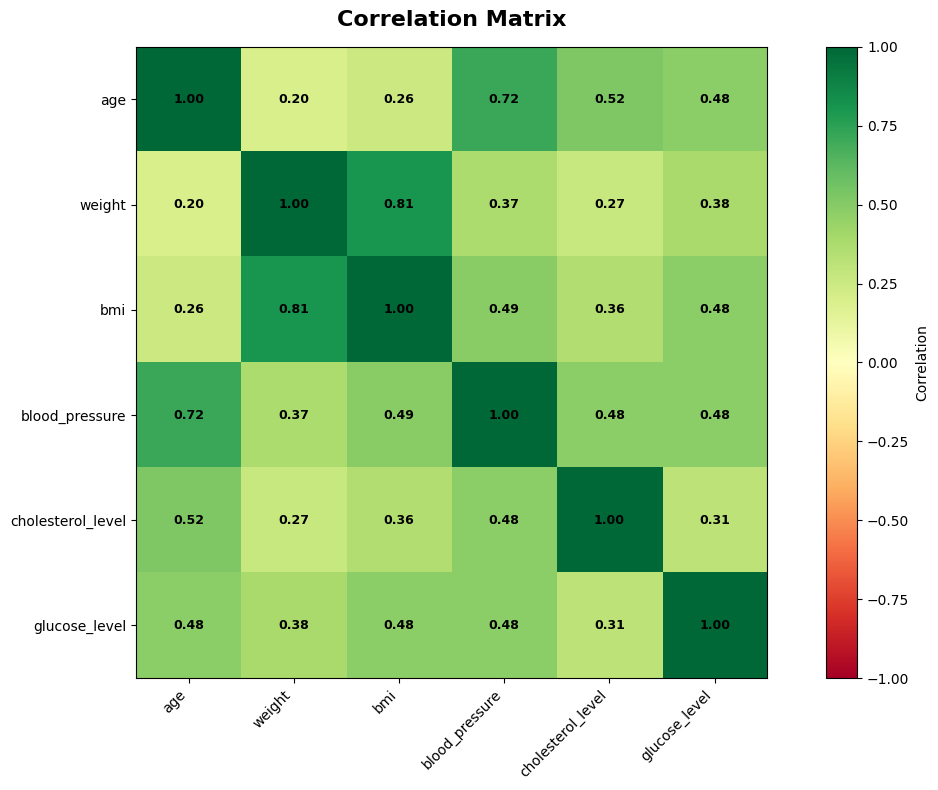

In [51]:
plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Show correlation values inside cells
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        
        plt.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

plt.colorbar(label="Correlation")

plt.title(
    "Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

#### Smoking vs Diabetes Chart

In [52]:
diabetes_rate = (
    pd.crosstab(
        df["smoking_status"],
        df["diabetes"],
        normalize="index"
    )[True] * 100
)

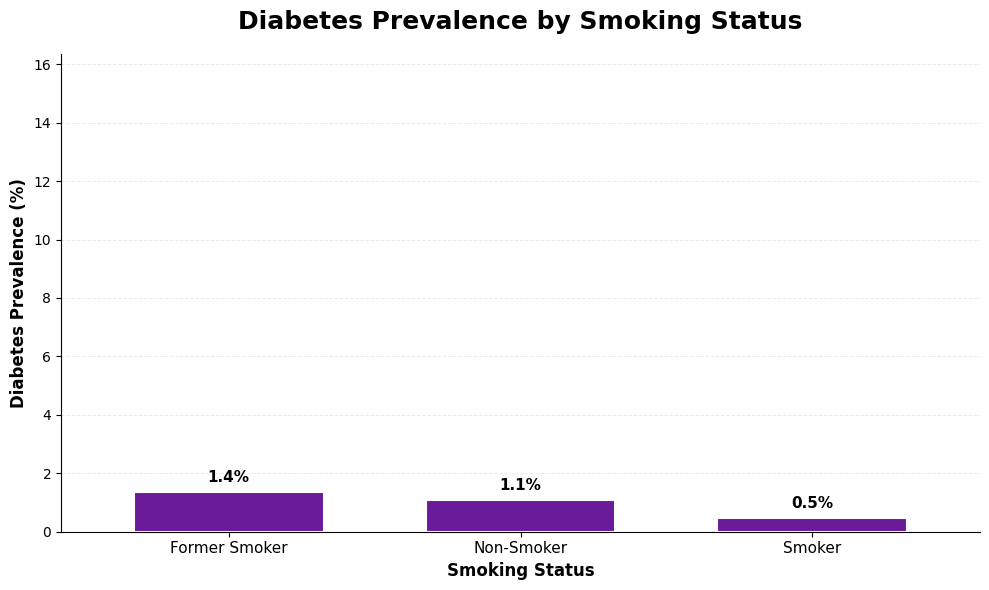

In [53]:
ax = diabetes_rate.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.65,
    color="#6A1B9A",
    edgecolor="white",
    linewidth=1.5
)

# Percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Diabetes Prevalence by Smoking Status",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Smoking Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Diabetes Prevalence (%)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(fontsize=10)

# Professional grid
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylim(0, max(diabetes_rate) + 15)

plt.tight_layout()
plt.show()

#### Age Group vs Diabetes Chart

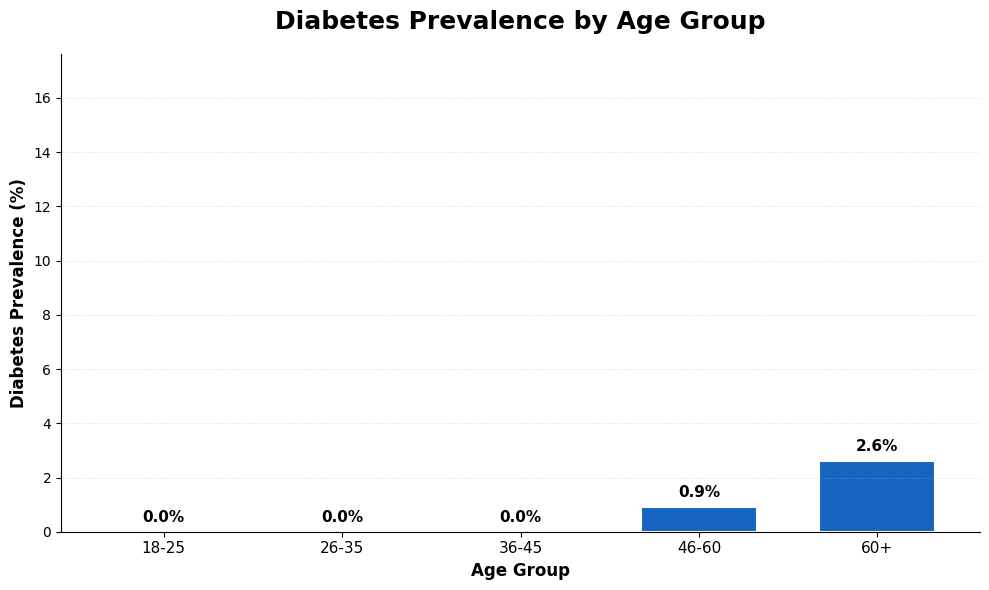

In [54]:
age_diabetes = (
    df.groupby("age_group")["diabetes"]
    .mean() * 100
)

ax = age_diabetes.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.65,
    color="#1565C0",
    edgecolor="white",
    linewidth=1.5
)

# Percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Diabetes Prevalence by Age Group",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Age Group",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Diabetes Prevalence (%)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(fontsize=10)

# Professional grid
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylim(0, max(age_diabetes) + 15)

plt.tight_layout()
plt.show()
plt.show()

In [55]:
# Recalculate all final p-values for the summary table

# 1. t-test
t_test_result = stats.ttest_ind(
    smoker_bmi,
    non_smoker_bmi,
    equal_var=False
)

t_p = t_test_result.pvalue

In [56]:
# 2. Chi-square
chi_test_result = stats.chi2_contingency(
    contingency_table
)

chi_p = chi_test_result[1]

In [57]:
# 3. ANOVA
anova_result = stats.f_oneway(*age_groups)

anova_p = anova_result.pvalue

In [58]:
# 4. Correlation
corr_p = p_correlation

final_results = pd.DataFrame({
    "Test": [
        "Independent t-test",
        "Chi-square test",
        "One-way ANOVA",
        "Pearson Correlation"
    ],
    
    "Comparison": [
        "BMI: Smoker vs Non-Smoker",
        "Smoking Status vs Diabetes",
        "Diabetes Rate across Age Groups",
        "Age vs BMI"
    ],
    
    "p-value": [
        t_p,
        chi_p,
        anova_p,
        corr_p
    ]
})

In [59]:
final_results["Decision"] = np.where(
    final_results["p-value"] < 0.05,
    "Reject H₀",
    "Fail to reject H₀"
)

final_results.round(6)

,Test,Comparison,p-value,Decision
0,Independent t-test,BMI: Smoker vs Non-Smoker,0.02,Reject H₀
1,Chi-square test,Smoking Status vs Diabetes,0.62,Fail to reject H₀
2,One-way ANOVA,Diabetes Rate across Age Groups,0.01,Reject H₀
3,Pearson Correlation,Age vs BMI,0.00,Reject H₀


### Final Conclusion

The statistical analysis was performed at a 5% significance level (α = 0.05).

#### Major Findings

1. **Independent t-test:** The test evaluates whether mean BMI differs between smokers and non-smokers. The decision is based on the calculated p-value.

2. **Chi-square test:** The test evaluates the association between smoking status and diabetes. If the p-value is greater than 0.05, we fail to reject H₀ and conclude that there is insufficient evidence of an association.

3. **ANOVA:** The test evaluates whether diabetes prevalence differs across age groups. A p-value below 0.05 indicates that at least one age group has a significantly different diabetes prevalence.

4. **Covariance:** Covariance indicates the direction in which age and BMI vary together.

5. **Correlation:** Pearson correlation measures the strength and direction of the linear relationship between age and BMI.



#### Overall Conclusion


Inferential statistical techniques provide a systematic way to make decisions from sample data. The results of this project demonstrate how confidence intervals, hypothesis testing, t-tests, chi-square tests, ANOVA, covariance, and correlation can be applied to health-related data.

The results represent statistical patterns in the given dataset and should not be interpreted as medical or causal conclusions.